In [1]:
# Cell 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2: Load RetailRocket Dataset
print("Loading RetailRocket dataset...")
events = pd.read_csv('events.csv')  # 2.7M rows: visitorid,timestamp,visitorid,itemid,event
events['visitorid'] = events['visitorid'].astype('int64')  # FIX
events['itemid'] = events['itemid'].astype('int64')        # FIX

item_props1 = pd.read_csv('item_properties_part1.csv')
item_props2 = pd.read_csv('item_properties_part2.csv')
category_tree = pd.read_csv('category_tree.csv')

print(f"Events shape: {events.shape}")
print(f"Events distribution:\n{events['event'].value_counts()}")

Loading RetailRocket dataset...
Events shape: (2756101, 5)
Events distribution:
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [3]:
# Cell 3: Event Mapping & Weights (Implicit Signals)
event_mapping = {90: 'view', 23: 'addtocart', 21: 'transaction'}
event_weights = {90: 1.0, 23: 1.5, 21: 3.0}  # Confidence weights

events['event_type'] = events['event'].map(event_mapping)
events['weight'] = events['event'].map(event_weights)
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')

print("Event weights applied: view=1.0, addtocart=1.5, transaction=3.0")

Event weights applied: view=1.0, addtocart=1.5, transaction=3.0


In [4]:

# Cell 4: Temporal Splits (Production-Realistic)
events = events.sort_values('timestamp')
total_events = len(events)

split_points = {
    'train_end': int(0.8 * total_events),
    'valid_end': int(0.9 * total_events)
}

train = events.iloc[:split_points['train_end']].copy()
valid = events.iloc[split_points['train_end']:split_points['valid_end']].copy()
test = events.iloc[split_points['valid_end']:].copy()

print(f"Train: {len(train):,}, Valid: {len(valid):,}, Test: {len(test):,}")


Train: 2,204,880, Valid: 275,610, Test: 275,611


In [5]:
# Cell 5: Session Windows (30-min browsing journeys)
def create_sessions(df, window_minutes=30):
    """Group events into 30-min sessions by visitor"""
    df = df.copy()
    df['session_start'] = df.groupby('visitorid')['timestamp'].transform('min')
    df['session_offset'] = (df['timestamp'] - df['session_start']).dt.total_seconds() / 60
    
    # New session if >30min gap
    df['session_id'] = (df['session_offset'] > window_minutes).cumsum()
    df['session_id'] = df['visitorid'].astype(str) + '_' + df['session_id'].astype(str)
    
    return df

train = create_sessions(train)
valid = create_sessions(valid)
test = create_sessions(test)

print("30-min session windows created")

30-min session windows created


In [6]:
# Cell 6: FIXED - Returns ONLY 2 values (sparse_matrix, interactions)
def build_user_item_sparse(df, alpha=15):
    """Production-ready sparse matrix - FIXED unpacking"""
    print("🔄 Building sparse matrix...")
    
    # Fix dtypes FIRST
    df = df.copy()
    df['visitorid'] = df['visitorid'].astype('int64')
    df['itemid'] = df['itemid'].astype('int64')
    
    # Aggregate interactions
    interactions = df.groupby(['visitorid', 'itemid'])['weight'].sum().reset_index()
    interactions['confidence'] = 1 + alpha * interactions['weight']
    
    # Categorical codes → int32
    user_codes = pd.Categorical(interactions['visitorid']).codes.astype(np.int32)
    item_codes = pd.Categorical(interactions['itemid']).codes.astype(np.int32)
    
    # Build sparse matrix
    data = interactions['confidence'].astype(np.float32).values
    sparse_matrix = sparse.csr_matrix((data, (user_codes, item_codes)),
                                    shape=(interactions['visitorid'].nunique(), 
                                          interactions['itemid'].nunique()))
    
    print(f"✅ Shape: {sparse_matrix.shape}, nnz: {sparse_matrix.nnz:,}")
    return sparse_matrix, interactions  # ONLY 2 VALUES

# FIXED CALL - Match return values
train_sparse, train_interactions = build_user_item_sparse(train)
valid_sparse, valid_interactions = build_user_item_sparse(valid)

print(f"✅ Train: {train_sparse.shape}, Valid: {valid_sparse.shape}")

🔄 Building sparse matrix...
✅ Shape: (1123767, 212915), nnz: 1,713,174
🔄 Building sparse matrix...
✅ Shape: (156951, 77696), nnz: 219,104
✅ Train: (1123767, 212915), Valid: (156951, 77696)


In [8]:
# Cell 7: FIXED Feature Store (No n_users/n_items unpacking)
Path("feature_store").mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)

# Save sparse matrices only
with open('feature_store/train_sparse.pkl', 'wb') as f:
    pickle.dump({'sparse': train_sparse}, f)

with open('feature_store/valid_sparse.pkl', 'wb') as f:
    pickle.dump({'sparse': valid_sparse}, f)

train.to_parquet('feature_store/train_sessions.parquet')
valid.to_parquet('feature_store/valid_sessions.parquet')

print("✅ Feature store saved!")


✅ Feature store saved!


In [9]:
# Cell 8: Sampling for Cold-Start Simulation
cold_start_users = train.groupby('visitorid').size()
cold_start_users = cold_start_users[cold_start_users < 5].index.tolist()

print(f"Cold-start users (<5 interactions): {len(cold_start_users)}")

Cold-start users (<5 interactions): 1058120


In [10]:

# Cell 9: Item Metadata Processing
item_props = pd.concat([item_props1, item_props2])
item_features = item_props.pivot_table(
    index='itemid', columns='property', values='value', aggfunc='first'
).reset_index()

item_features.to_parquet('feature_store/item_features.parquet')
print("Item metadata processed")

Item metadata processed


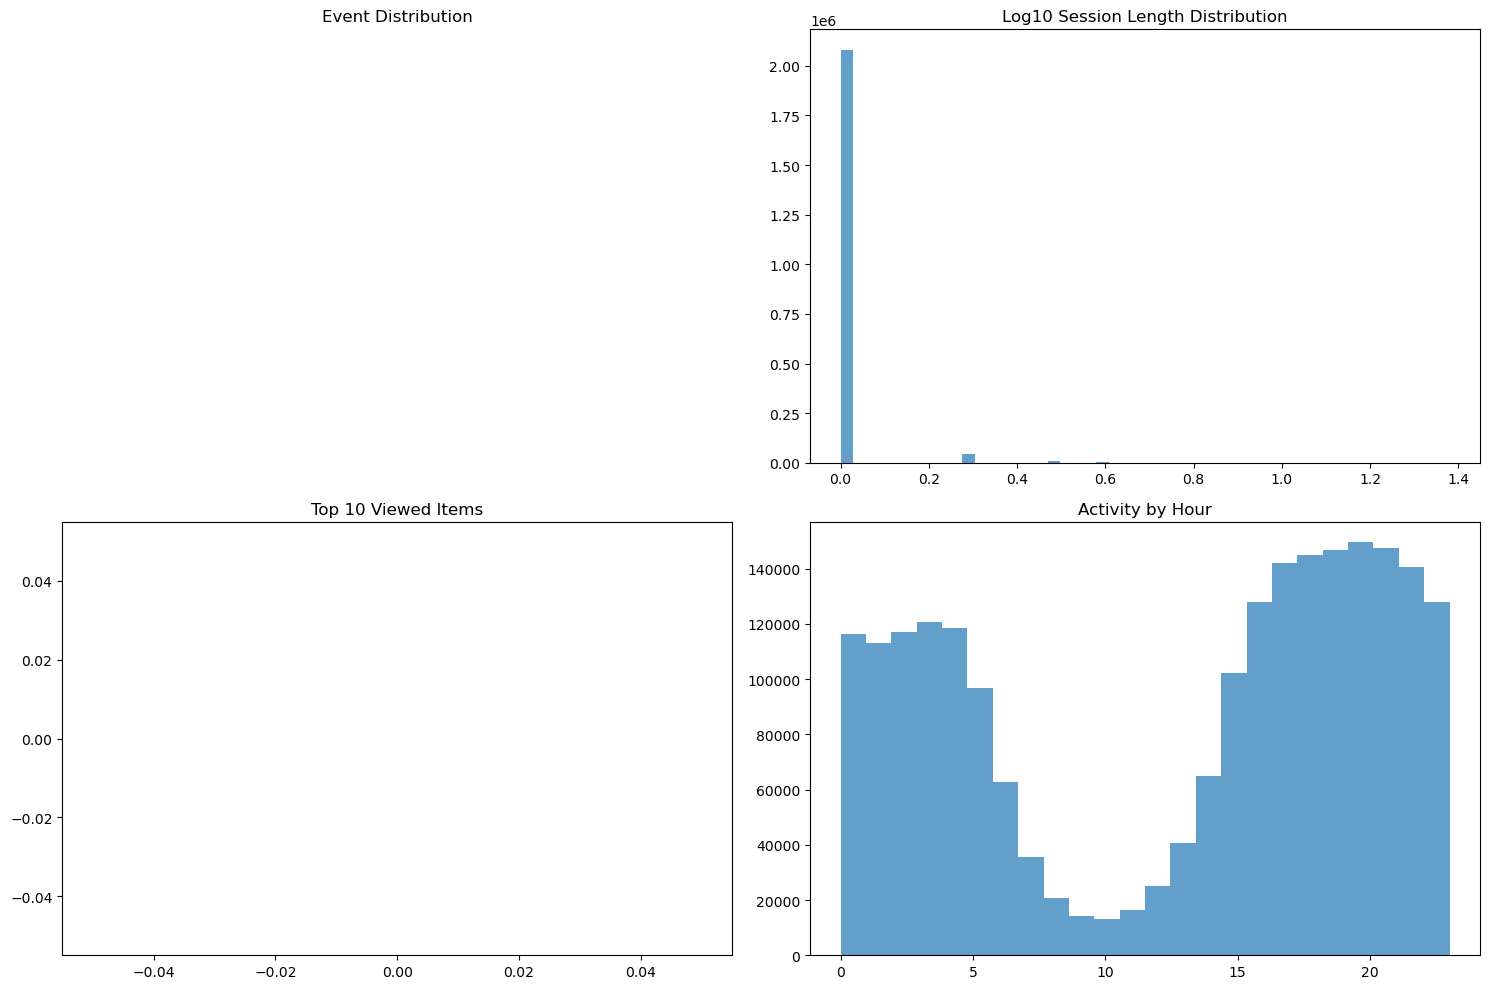

✅ Stage 0 COMPLETE: Temporal splits, session windows, sparse matrices, feature store ready!


In [11]:
# Cell 10: EDA Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Event distribution
axes[0,0].pie(events['event_type'].value_counts().values, 
              labels=events['event_type'].value_counts().index, autopct='%1.1f%%')
axes[0,0].set_title('Event Distribution')

# Session length distribution
session_lengths = train.groupby('session_id').size()
axes[0,1].hist(np.log10(session_lengths), bins=50, alpha=0.7)
axes[0,1].set_title('Log10 Session Length Distribution')

# Top items by views
top_items = train[train.event_type=='view']['itemid'].value_counts().head(10)
axes[1,0].bar(range(len(top_items)), top_items.values)
axes[1,0].set_title('Top 10 Viewed Items')

# Temporal trend
train['hour'] = train['timestamp'].dt.hour
axes[1,1].hist(train['hour'], bins=24, alpha=0.7)
axes[1,1].set_title('Activity by Hour')

plt.tight_layout()
plt.savefig('eda_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Stage 0 COMPLETE: Temporal splits, session windows, sparse matrices, feature store ready!")

In [12]:
import pandas as pd
import numpy as np
from scipy import sparse
import pickle
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# CREATE DIRECTORIES FIRST
Path("feature_store").mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)

print("✅ Directories ready")

# LOAD DATA - FORCE INT64
print("🔄 Loading RetailRocket...")
events = pd.read_csv('events.csv')
events['visitorid'] = events['visitorid'].astype('int64')
events['itemid'] = events['itemid'].astype('int64')
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')

item_props1 = pd.read_csv('item_properties_part1.csv')
item_props2 = pd.read_csv('item_properties_part2.csv')

print(f"Events: {events.shape}")

# EVENT WEIGHTS
event_weights = {90: 1.0, 23: 1.5, 21: 3.0}
events['weight'] = events['event'].map(event_weights)
events['event_type'] = events['event'].map({90: 'view', 23: 'addtocart', 21: 'transaction'})

# TEMPORAL SPLIT
events = events.sort_values('timestamp')
n_events = len(events)
train = events.iloc[:int(0.8*n_events)].copy()
valid = events.iloc[int(0.8*n_events):int(0.9*n_events)].copy()
test = events.iloc[int(0.9*n_events):].copy()

# SESSION WINDOWS (30min)
def create_sessions(df):
    df = df.copy()
    df['session_offset'] = df.groupby('visitorid')['timestamp'].diff().dt.total_seconds().fillna(0) / 60
    df['session_id'] = (df['session_offset'] > 30).cumsum()
    df['session_id'] = df['visitorid'].astype(str) + '_' + df['session_id'].astype(str)
    return df

train = create_sessions(train)
valid = create_sessions(valid)

# FIXED SPARSE MATRIX - NO dtype errors
def build_sparse(df, alpha=15):
    df = df.copy()
    df['visitorid'] = df['visitorid'].astype('int64')
    df['itemid'] = df['itemid'].astype('int64')
    
    # Aggregate + confidence
    interactions = df.groupby(['visitorid', 'itemid'])['weight'].sum().reset_index()
    interactions['confidence'] = 1 + alpha * interactions['weight']
    
    # Safe categorical encoding
    user_map = {uid: i for i, uid in enumerate(interactions['visitorid'].unique())}
    item_map = {iid: i for i, iid in enumerate(interactions['itemid'].unique())}
    
    user_codes = interactions['visitorid'].map(user_map).astype(np.int32)
    item_codes = interactions['itemid'].map(item_map).astype(np.int32)
    data = interactions['confidence'].astype(np.float32)
    
    sparse_mat = sparse.csr_matrix((data, (user_codes, item_codes)),
                                 shape=(len(user_map), len(item_map)))
    return sparse_mat

train_sparse = build_sparse(train)
valid_sparse = build_sparse(valid)

print(f"✅ Sparse matrices: train={train_sparse.shape}, valid={valid_sparse.shape}")

# SAVE FEATURE STORE
with open('feature_store/train_sparse.pkl', 'wb') as f:
    pickle.dump({'sparse': train_sparse}, f)
with open('feature_store/valid_sparse.pkl', 'wb') as f:
    pickle.dump({'sparse': valid_sparse}, f)

train.to_parquet('feature_store/train_sessions.parquet')
valid.to_parquet('feature_store/valid_sessions.parquet')

print("🎉 STAGE 0 COMPLETE!")


✅ Directories ready
🔄 Loading RetailRocket...
Events: (2756101, 5)
✅ Sparse matrices: train=(1123767, 212915), valid=(156951, 77696)
🎉 STAGE 0 COMPLETE!
